## Lenet5

The first layer is the input layer with feature map size 32X32X1.

Then we have the first convolution layer with 6 filters of size 5X5 and stride is 1. The activation function used at his layer is tanh. The output feature map is  28X28X6.

Next, we have an average pooling layer with filter size 2X2 and stride 1. The resulting feature map is 14X14X6. Since the pooling layer doesn’t affect the number of channels.

After this comes the second convolution layer with 16 filters of 5X5 and stride 1. Also, the activation function is tanh. Now the output size is 10X10X16.

Again comes the other average pooling layer of 2X2 with stride 2. As a result, the size of the feature map reduced to 5X5X16.

The final pooling layer has 120 filters of 5X5  with stride 1 and activation function tanh. Now the output size is 120.

The next is a fully connected layer with 84 neurons that result in the output to 84 values and the activation function used here is again tanh.

The last layer is the output layer with 10 neurons and  Softmax function. The Softmax gives the probability that a data point belongs to a particular class. The highest value is then predicted.

This is the entire architecture of the Lenet-5 model. The number of trainable parameters of this architecture is around sixty thousand.

=== 1. IMPORT LIBRARIES ===

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torch.utils.data.sampler import SubsetRandomSampler

In [2]:
# Set your download directory
DOWNLOAD_PATH = "D:\\Sj\\PreThesis\\Data\\Week2"
os.makedirs(DOWNLOAD_PATH, exist_ok=True)

print(f"Download path: {DOWNLOAD_PATH}")

Download path: D:\Sj\PreThesis\Data\Week2


=== 2. SETUP PATHS AND DEVICE ===

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Download path: {DOWNLOAD_PATH}")

Device: cpu
Download path: D:\Sj\PreThesis\Data\Week2


=== 3. DATA LOADING WITH TRANSFORMATIONS ===

In [4]:
print("\n" + "="*50)
print("STEP 1: LOADING AND PREPARING MNIST DATA")
print("="*50)

# Define transformations (including normalization)
# LeNet-5 expects 32x32 input, but MNIST is 28x28
transform = transforms.Compose([
    transforms.Resize((32, 32)),          # Resize to 32x32 for LeNet-5
    transforms.ToTensor(),                # Convert to tensor [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))  # Standard MNIST normalization
])

# Load MNIST dataset
print("Downloading/loading MNIST dataset...")
train_dataset = torchvision.datasets.MNIST(
    root=DOWNLOAD_PATH,
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root=DOWNLOAD_PATH,
    train=False,
    download=True,
    transform=transform
)

print(f"✓ Training samples: {len(train_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")


STEP 1: LOADING AND PREPARING MNIST DATA
Downloading/loading MNIST dataset...
✓ Training samples: 60000
✓ Test samples: 10000


=== 4. DATA VISUALIZATION ===


Visualizing sample images...


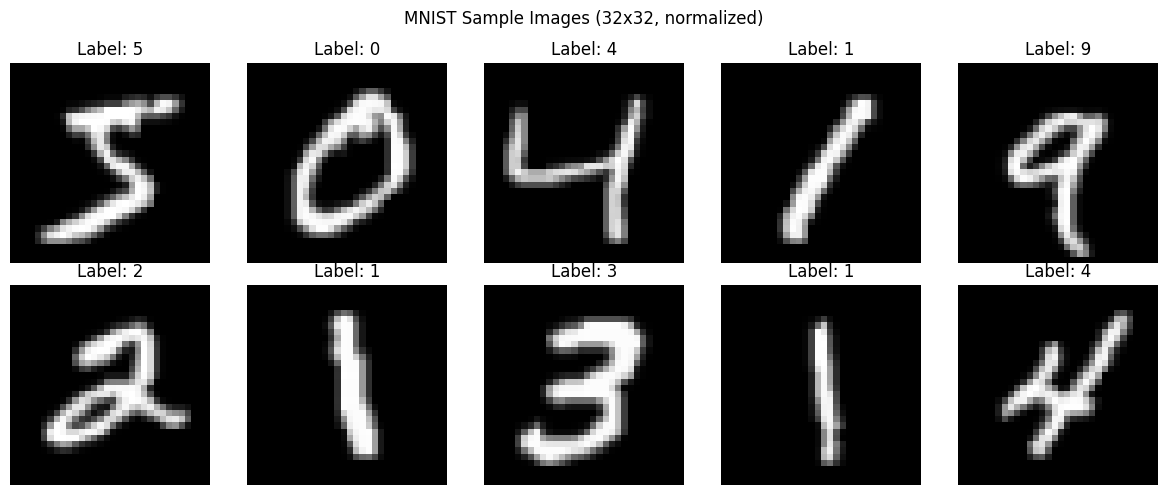


Data shape check:
  - Single image shape: torch.Size([1, 32, 32])
  - Pixel range: [-0.424, 2.796]
  - Mean: 0.025, Std: 0.953


In [5]:
print("\nVisualizing sample images...")

# Visualize first 10 training images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = train_dataset[i]
    ax = axes[i//5, i%5]
    ax.imshow(img.squeeze(), cmap='gray')  # Remove channel dim for display
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.suptitle("MNIST Sample Images (32x32, normalized)")
plt.tight_layout()
plt.show()

# Check data statistics
sample_img, sample_label = train_dataset[0]
print(f"\nData shape check:")
print(f"  - Single image shape: {sample_img.shape}")  # Should be [1, 32, 32]
print(f"  - Pixel range: [{sample_img.min():.3f}, {sample_img.max():.3f}]")
print(f"  - Mean: {sample_img.mean():.3f}, Std: {sample_img.std():.3f}")

=== 5. CREATE TRAIN/VALIDATION SPLIT ===

In [6]:
print("\n" + "="*50)
print("STEP 2: CREATING TRAIN/VALIDATION SPLIT")
print("="*50)

# Split training data into train (80%) and validation (20%)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

print(f"  Training set: {len(train_data)} samples")
print(f"  Validation set: {len(val_data)} samples")
print(f"  Test set: {len(test_dataset)} samples")

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



STEP 2: CREATING TRAIN/VALIDATION SPLIT
  Training set: 48000 samples
  Validation set: 12000 samples
  Test set: 10000 samples


=== 6. DEFINE LeNet-5 MODEL ===

In [7]:
print("\n" + "="*50)
print("STEP 3: BUILDING LeNet-5 ARCHITECTURE")
print("="*50)

class LeNet5(nn.Module):
    """
    LeNet-5 Architecture (Simplified):
    Input: 1x32x32 (Grayscale image)
    Conv1: 6 filters of 5x5 → 6x28x28
    AvgPool1: 2x2 → 6x14x14
    Conv2: 16 filters of 5x5 → 16x10x10
    AvgPool2: 2x2 → 16x5x5
    Flatten: 16*5*5 = 400
    FC1: 400 → 120
    FC2: 120 → 84
    FC3: 84 → 10 (output classes)
    """

    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(
            # Layer 1: Conv + Tanh + AvgPool
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),  # Original uses AvgPool, but MaxPool is common now

            # Layer 2: Conv + Tanh + AvgPool
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
        )

        # Classification layers
        self.classifier = nn.Sequential(
            nn.Linear(16 * 5 * 5, 120),  # Flattened features: 16*5*5 = 400
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.classifier(x)
        return x

# Create model instance
model = LeNet5(num_classes=10).to(device)
print("✓ LeNet-5 model created successfully!")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")



STEP 3: BUILDING LeNet-5 ARCHITECTURE
✓ LeNet-5 model created successfully!
  Total parameters: 61,706


=== 7. VISUALIZE DIMENSION CHANGES (KEY REQUIREMENT) ===

In [8]:
print("\n" + "="*50)
print("STEP 4: VISUALIZING DIMENSION CHANGES")
print("="*50)
print("This shows how data dimensions change through each layer:")

def visualize_dimensions(model, sample_input):
    """Manually track and print dimension changes through each layer"""
    print(f"\nInput shape: {sample_input.shape}")

    x = sample_input.clone()
    layer_counter = 1

    # Go through each layer in features
    for i, layer in enumerate(model.features):
        x = layer(x)
        if isinstance(layer, nn.Conv2d):
            print(f"  Conv{layer_counter}: {x.shape}")
            layer_counter += 1
        elif isinstance(layer, nn.AvgPool2d):
            print(f"  Pool{layer_counter-1}: {x.shape}")
        elif isinstance(layer, nn.Tanh):
            print(f"  Tanh activation: No dimension change")

    print(f"  After feature extraction: {x.shape}")

    # Flatten
    x = torch.flatten(x, 1)
    print(f"  After flattening: {x.shape}")

    # Go through classifier layers
    for i, layer in enumerate(model.classifier):
        x = layer(x)
        if isinstance(layer, nn.Linear):
            if i == 0:
                print(f"  FC1 (400→120): {x.shape}")
            elif i == 2:
                print(f"  FC2 (120→84): {x.shape}")
            elif i == 4:
                print(f"  FC3 (84→10): {x.shape}")
        elif isinstance(layer, nn.Tanh):
            print(f"  Tanh activation: No dimension change")

    return x

# Test with a sample batch
sample_batch, sample_labels = next(iter(train_loader))
sample_batch = sample_batch[:1].to(device)  # Take just one sample

print("\nDimension flow for a single image:")
output = visualize_dimensions(model, sample_batch)



STEP 4: VISUALIZING DIMENSION CHANGES
This shows how data dimensions change through each layer:

Dimension flow for a single image:

Input shape: torch.Size([1, 1, 32, 32])
  Conv1: torch.Size([1, 6, 28, 28])
  Tanh activation: No dimension change
  Pool1: torch.Size([1, 6, 14, 14])
  Conv2: torch.Size([1, 16, 10, 10])
  Tanh activation: No dimension change
  Pool2: torch.Size([1, 16, 5, 5])
  After feature extraction: torch.Size([1, 16, 5, 5])
  After flattening: torch.Size([1, 400])
  FC1 (400→120): torch.Size([1, 120])
  Tanh activation: No dimension change
  FC2 (120→84): torch.Size([1, 84])
  Tanh activation: No dimension change
  FC3 (84→10): torch.Size([1, 10])


=== 8. TRAINING SETUP ===

In [9]:
print("\n" + "="*50)
print("STEP 5: TRAINING CONFIGURATION")
print("="*50)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: SGD (lr=0.01, momentum=0.9)")
print(f"  Batch size: {batch_size}")
print(f"  Training epochs: 10")



STEP 5: TRAINING CONFIGURATION
  Loss function: CrossEntropyLoss
  Optimizer: SGD (lr=0.01, momentum=0.9)
  Batch size: 64
  Training epochs: 10


=== 9. TRAINING LOOP ===

In [10]:
print("\n" + "="*50)
print("STEP 6: TRAINING LeNet-5")
print("="*50)

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f"    Batch {batch_idx}/{len(dataloader)}: Loss = {loss.item():.4f}")

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

# Training history
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Start training
num_epochs = 10
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}:")

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Update learning rate
    scheduler.step()

    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")



STEP 6: TRAINING LeNet-5

Epoch 1/10:
    Batch 0/750: Loss = 2.3032
    Batch 100/750: Loss = 0.6081
    Batch 200/750: Loss = 0.1146
    Batch 300/750: Loss = 0.4595
    Batch 400/750: Loss = 0.3576
    Batch 500/750: Loss = 0.1937
    Batch 600/750: Loss = 0.1646
    Batch 700/750: Loss = 0.2303
  Train Loss: 0.4322, Train Acc: 87.93%
  Val Loss: 0.1691, Val Acc: 95.26%

Epoch 2/10:
    Batch 0/750: Loss = 0.1578
    Batch 100/750: Loss = 0.3383
    Batch 200/750: Loss = 0.0982
    Batch 300/750: Loss = 0.0771
    Batch 400/750: Loss = 0.1711
    Batch 500/750: Loss = 0.0401
    Batch 600/750: Loss = 0.0556
    Batch 700/750: Loss = 0.1064
  Train Loss: 0.1236, Train Acc: 96.32%
  Val Loss: 0.1000, Val Acc: 96.94%

Epoch 3/10:
    Batch 0/750: Loss = 0.0668
    Batch 100/750: Loss = 0.2256
    Batch 200/750: Loss = 0.1121
    Batch 300/750: Loss = 0.0894
    Batch 400/750: Loss = 0.0852
    Batch 500/750: Loss = 0.1505
    Batch 600/750: Loss = 0.0615
    Batch 700/750: Loss = 0.04

=== 10. EVALUATION ON TEST SET ===

In [11]:
print("\n" + "="*50)
print("STEP 7: FINAL EVALUATION ON TEST SET")
print("="*50)

test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"✓ Test Loss: {test_loss:.4f}")
print(f"✓ Test Accuracy: {test_acc:.2f}%")


STEP 7: FINAL EVALUATION ON TEST SET
✓ Test Loss: 0.0372
✓ Test Accuracy: 98.76%


=== 11. VISUALIZE TRAINING RESULTS ===


STEP 8: VISUALIZING RESULTS


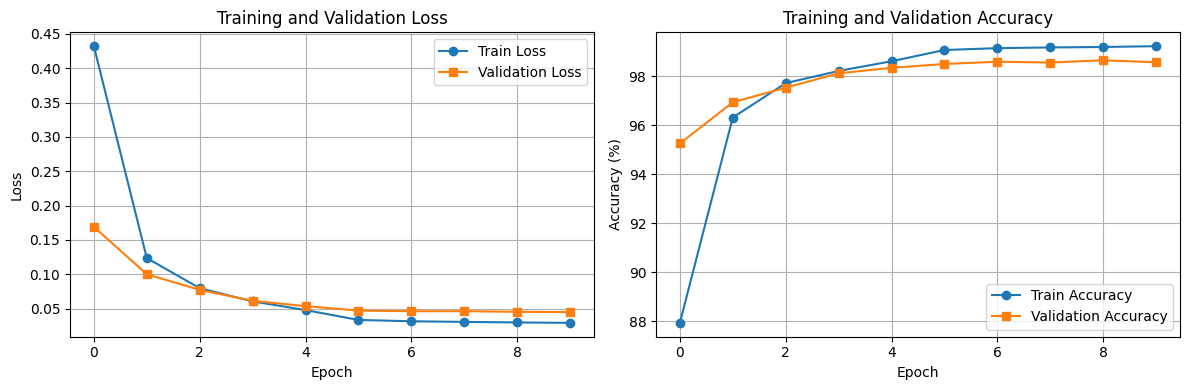

In [12]:
print("\n" + "="*50)
print("STEP 8: VISUALIZING RESULTS")
print("="*50)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot losses
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Plot accuracies
axes[1].plot(train_accs, label='Train Accuracy', marker='o')
axes[1].plot(val_accs, label='Validation Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

=== 12. SAVE THE MODEL ===

In [13]:
print("\n" + "="*50)
print("STEP 9: SAVING THE TRAINED MODEL")
print("="*50)

# Create the new directory path
WEEK2_PATH = r"D:\Sj\PreThesis\Weeks\Week2"
os.makedirs(WEEK2_PATH, exist_ok=True)

# Save model with your specified filename
model_save_path = os.path.join(WEEK2_PATH, "lenet5.pth")
torch.save({
    'model_state_dict': model.state_dict(),
    'test_accuracy': test_acc,
    'epochs_trained': num_epochs,
    'model_architecture': 'LeNet5',
    'dataset': 'MNIST',
    'input_shape': (1, 32, 32),
    'num_classes': 10,
    'training_date': '2024'  # You can update this with actual date
}, model_save_path)

print(f"✓ Model saved to: {model_save_path}")
print(f"✓ Final test accuracy: {test_acc:.2f}%")

# Also save a text file with model summary
summary_path = os.path.join(WEEK2_PATH, "model_summary.txt")
with open(summary_path, 'w') as f:
    f.write("="*50 + "\n")
    f.write("LeNet-5 Model Summary\n")
    f.write("="*50 + "\n\n")
    f.write(f"Model: LeNet-5\n")
    f.write(f"Dataset: MNIST\n")
    f.write(f"Input shape: 1×32×32\n")
    f.write(f"Number of classes: 10\n")
    f.write(f"Training epochs: {num_epochs}\n")
    f.write(f"Test accuracy: {test_acc:.2f}%\n")
    f.write(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}\n")
    f.write(f"Saved at: {model_save_path}\n")
    f.write("\nArchitecture:\n")
    f.write("-"*30 + "\n")
    f.write(str(model))

print(f"✓ Model summary saved to: {summary_path}")
print(f"✓ Directory created: {WEEK2_PATH}")


STEP 9: SAVING THE TRAINED MODEL
✓ Model saved to: D:\Sj\PreThesis\Weeks\Week2\lenet5.pth
✓ Final test accuracy: 98.76%
✓ Model summary saved to: D:\Sj\PreThesis\Weeks\Week2\model_summary.txt
✓ Directory created: D:\Sj\PreThesis\Weeks\Week2


=== 13. MAKE PREDICTIONS ON SAMPLE IMAGES ===


STEP 10: MAKING PREDICTIONS


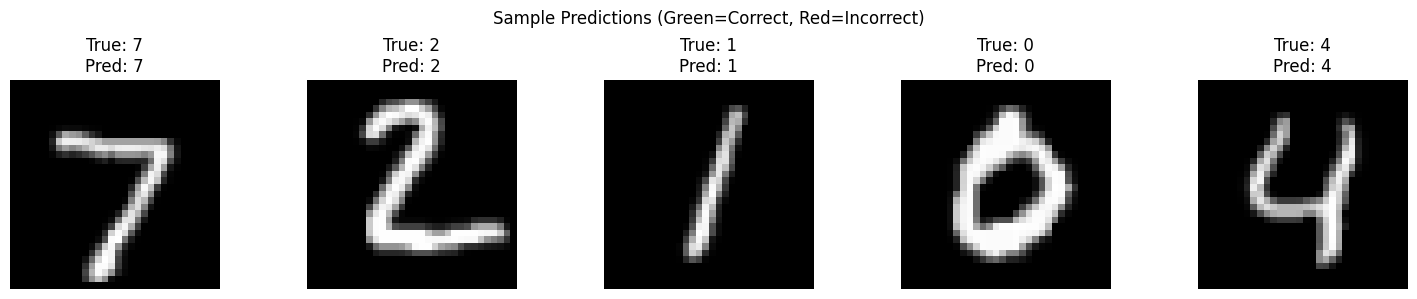

In [14]:
print("\n" + "="*50)
print("STEP 10: MAKING PREDICTIONS")
print("="*50)

# Get some test images
test_samples, test_labels = next(iter(test_loader))
test_samples = test_samples[:5].to(device)
test_labels = test_labels[:5]

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(test_samples)
    _, predictions = outputs.max(1)

# Visualize predictions
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = test_samples[i].cpu().squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {test_labels[i]}\nPred: {predictions[i].item()}")
    axes[i].axis('off')

    # Highlight correct/wrong predictions
    if test_labels[i] == predictions[i].item():
        axes[i].spines['bottom'].set_color('green')
        axes[i].spines['top'].set_color('green')
        axes[i].spines['left'].set_color('green')
        axes[i].spines['right'].set_color('green')
        axes[i].spines['bottom'].set_linewidth(3)
        axes[i].spines['top'].set_linewidth(3)
        axes[i].spines['left'].set_linewidth(3)
        axes[i].spines['right'].set_linewidth(3)
    else:
        axes[i].spines['bottom'].set_color('red')
        axes[i].spines['top'].set_color('red')
        axes[i].spines['left'].set_color('red')
        axes[i].spines['right'].set_color('red')
        axes[i].spines['bottom'].set_linewidth(3)
        axes[i].spines['top'].set_linewidth(3)
        axes[i].spines['left'].set_linewidth(3)
        axes[i].spines['right'].set_linewidth(3)

plt.suptitle("Sample Predictions (Green=Correct, Red=Incorrect)")
plt.tight_layout()
plt.show()